In [1]:
#Upload the CSV file containing the weather data recorded at Boston Logan Airport at various times of day, every day in the year 2012

import numpy as np
import pandas as pd
import datetime as dt
import scipy.stats as st
import matplotlib.pyplot as plt
import warnings
import os
from scipy import interpolate
import matplotlib.pyplot as plt
warnings.filterwarnings('ignore')

from google.colab import files
uploaded = files.upload()

for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))


TempDataFrame = pd.read_csv('BOS_DAILY_WEATHER.csv')

#Include only the dates/times and the hourly dry bulb temperature
TempDataFrame = TempDataFrame[['DATE_TIME', 'HourlyDryBulbTemperature']]

#Use Linear interpolation to fill in missing values
TempDataFrame['HourlyDryBulbTemperature'] = TempDataFrame['HourlyDryBulbTemperature'].interpolate()


Saving BOS_DAILY_WEATHER.csv to BOS_DAILY_WEATHER.csv
User uploaded file "BOS_DAILY_WEATHER.csv" with length 6831407 bytes


In [ ]:
#Convert date_times into dates (string) and hours (numeric)

date_times = TempDataFrame.DATE_TIME
format_string = '%Y-%m-%dT%H:%M:%S'
dates = []
hours = []
for i in range(len(date_times)):
  newdate = date_times[i].split('T', 1)[0]
  newhour = dt.datetime.strptime(date_times[i], format_string)
  newhour = newhour.timestamp()
  dates.append(newdate)
  hours.append(newhour)
dates = np.unique(dates)
hours = pd.Series(hours)





0        1.325379e+09
1        1.325380e+09
2        1.325383e+09
3        1.325386e+09
4        1.325390e+09
             ...     
14014    1.356991e+09
14015    1.356994e+09
14016    1.356998e+09
14017    1.356998e+09
14018    1.356998e+09
Length: 14019, dtype: float64


In [ ]:
#Use trapezoidal integration to estimate the daily average temperature from the hour by hour data

import time
dailyAvgTemp = np.zeros(shape = (len(dates), 1))
for i in range(len(dates)):
    isDay = date_times.str.contains(dates[i])
    dayHours = hours[isDay]
    hourlyTemps = TempDataFrame.HourlyDryBulbTemperature[isDay]
    start = dayHours.iloc[0]
    dayHours2 = dayHours - start
    dayHours3 = dayHours2/3600
    interval = dayHours3.iloc[-1] - dayHours3.iloc[0]

    if len(hourlyTemps) != 1:
      integral = np.trapezoid(hourlyTemps, dayHours3)
      avgTemp = integral/interval
      dailyAvgTemp[i] = avgTemp
    else:
      dailyAvgTemp[i] = hourlyTemps


In [ ]:
#Convert dates (string) into a numeric array
dateNum = np.zeros(shape = (len(dates), 1))
for i in range(len(dates)):
  dn =  dt.datetime.strptime(dates[i], '%Y-%m-%d')
  dn = dn.timestamp()
  dateNum[i] = dn
print(len(dateNum) == len(dailyAvgTemp))

True


[-1.71936084e-13  4.61535794e-04 -3.09661792e+05]


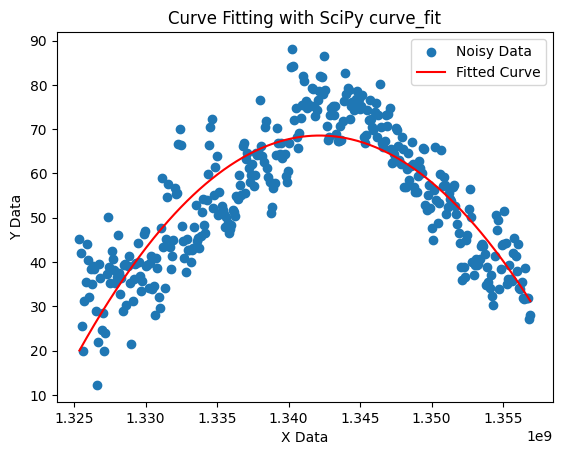

In [ ]:
#Fit daily temperatures to a curve, there are several models given, I ended up using model_fit4 (quadratic)

from scipy.stats import norm
from scipy.optimize import curve_fit

dateNum = dateNum.flatten()
dailyAvgTemp = dailyAvgTemp.flatten()

def model_fit_lin(x,a,b):
  y_pred = a + b*x
  return y_pred

def model_fit(x,a,b,a1,b1):
  omega = 2*np.pi/365
  y_pred = a + b*x + a1*np.cos(omega*x) + b1*np.sin(omega*x)
  return y_pred

def model_fit2(x,a,b,a1,b1, theta, phi):
  omega = 2*np.pi/365
  y_pred = a + b*x + a1*np.cos(omega*x + theta) + b1*np.sin(omega*x + phi)
  return y_pred

def model_fit3(x,a,b,a1,b1, theta, phi, omega):
  y_pred = a + b*x + a1*np.cos(omega*x + theta) + b1*np.sin(omega*x + phi)
  return y_pred

def model_fit4(x,a,b,c):
  return a*x**2 + b*x + c

def model_fit5(x,a,b,c,d):
  return a*np.cos(b*x-c) + d

def RSS(y, y_pred):
  return np.sqrt( (y - y_pred)**2).sum()

init_guess = [0,0,0]

model = model_fit4
params, cov = curve_fit(model, xdata = dateNum, ydata = dailyAvgTemp, p0 = init_guess)
print(params)

predicted_values = model(dateNum, *params)

plt.scatter(dateNum, dailyAvgTemp, label='Noisy Data')
plt.plot(dateNum, predicted_values, 'r-', label='Fitted Curve')
plt.title('Curve Fitting with SciPy curve_fit')
plt.xlabel('X Data')
plt.ylabel('Y Data')
plt.legend()
plt.show()

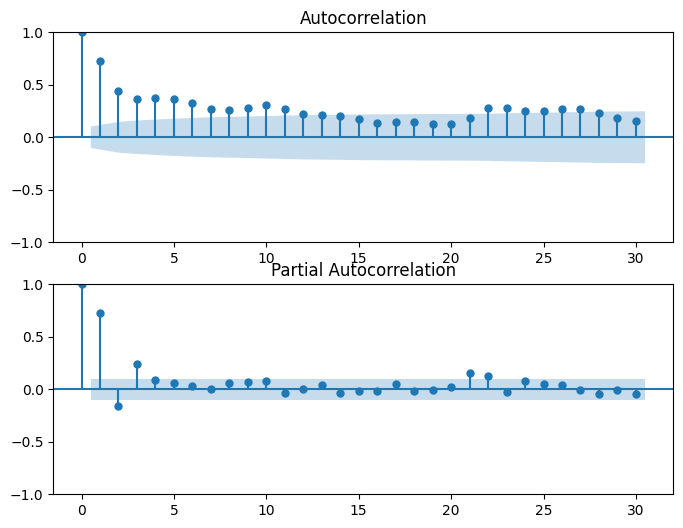

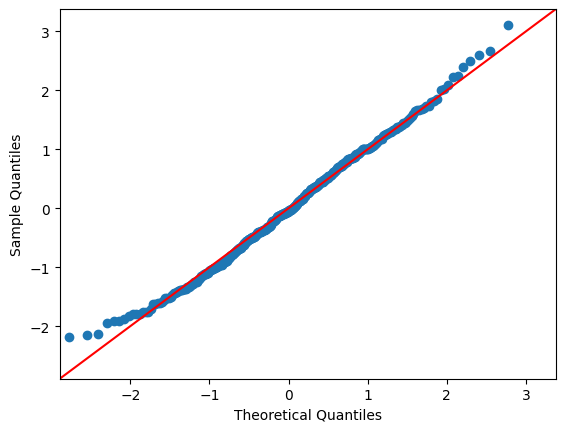

In [202]:
#Statistical analysis of the residuals, displays ACF, PACF, and QQ-plot. The results look pretty good!

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
import statsmodels.api as sm
residuals = dailyAvgTemp - predicted_values
#plt.plot(residuals)
figs, axs = plt.subplots(2, 1, figsize=(8, 6))
plot_acf(residuals, lags=30, alpha=0.05, ax = axs[0])
plot_pacf(residuals, lags=30, alpha=0.05, ax = axs[1])
standardize_residuals = (residuals - np.mean(residuals)) / np.std(residuals)
fig = sm.qqplot(standardize_residuals, line='45')
plt.show()

In [ ]:
#Estimates daily volatility by computing month-by-month standard deviations of the residuals. Then uses linear interpolation.
from scipy.interpolate import interp1d

def interp_volatility(query_pts):
  months = pd.to_datetime(dates).strftime('%m')
  df = pd.DataFrame({'dates':dates, 'residuals':residuals, 'months': months})
  volatility = df.groupby('months')['residuals'].std()
  sample_pts = np.linspace(0,365,len(volatility))
  interp_fun = interp1d(sample_pts, volatility)
  return interp_fun(query_pts)



In [ ]:
#Two functions. The first function, wiener_process_simulation simulates a wiener process
#The second function stochastic_integral calls wiener_process_simulation to generate a WP
#and then numerically integrates the function handle fun against that WP

def wiener_process_simulation(T, N=1000):
    """
    Simulates a standard Wiener process (Brownian motion) over a given time period.

    Args:
        T (float): Total time duration in days.
        N (int): Number of discrete time steps.

    Returns:
        tuple: (time_points, process_path)
    """
    time_points = np.linspace(0, T, N)
    dt = T / (N - 1) #
    sigma = np.sqrt(dt)
    dW = np.random.normal(loc=0.0, scale=sigma, size=N - 1)
    dW = np.insert(dW, 0, 0.0)
    process_path = np.cumsum(dW)

    return time_points, process_path

def stochastic_integral(endpt, fun, N = 1000):
  """
  Integrate the function handle fun(x) on the interval [0,endpt] against a Wiener Process
  (output by wiener_process_simulation above). Optional argument N = number of points at which fun
  is sampled

  """
  dt = endpt/N
  x = np.linspace(0, endpt, N-1)
  #print(len(x))

  f = fun(x)
  _,W = wiener_process_simulation(endpt, N-1)

  #print(len(W))

  dW = np.gradient(W)
  #print(len(dW))

  integral = np.trapz(f*dW, dx = dt)

  return integral



In [ ]:
#Simulate OU model for temperature time series

ndays = 366
days = np.arange(1,ndays,1)
kappa = 1

fun1 = lambda t: np.exp(-kappa*t)
fun2 = lambda t: np.exp(kappa*t) * interp_volatility(t)

def OU_temperature(day):
    T_bar = predicted_values[day]
    exp1 = fun1(day)
    exp2 = stochastic_integral(day, fun2, 100)
    return T_bar + exp1*exp2



In [ ]:
#Compute call/put option price based on season

May15 = np.where(dates == '2012-05-15')
Oct15 = np.where(dates == '2012-10-15')
Nov15 = np.where(dates == '2012-11-15')
Mar15 = np.where(dates == '2012-03-15')

HeatingSeason = np.arange(May15[0][0],Oct15[0][0])
#CoolingSeason = np.arange(Nov15[0][0]Mar15[0][0])

def GetCallPut(tempPath, option = 'Call', alpha = 2500, cap = 500_000, strike = 550, season = 'Cooling'):



    CDD_n = np.maximum(tempPath - 65, 0)
    HDD_n = np.maximum(65 - tempPath, 0)
    C_n = np.cumsum(CDD_n)
    H_n = np.cumsum(HDD_n)

    if season == 'Cooling':
      DD = C_n
    elif season == 'Heating':
      DD = H_n

    if option == 'Call':
        optionPrice = np.minimum( alpha * np.maximum(DD - strike, 0), cap)
    elif option == 'Put':
        optionPrice = np.minimum( alpha * np.maximum(strike - DD, 0), cap)
    return(optionPrice)





In [ ]:
#Generate stock paths MC style

npaths = 500

#CoolingSznStockPaths = np.zeros(shape = (npaths, len(CoolingSeason)))
HeatingSznStockPaths = np.zeros(shape = (npaths, len(HeatingSeason)))

#print(np.shape(CoolingSznStockPaths))
print(np.shape(HeatingSznStockPaths))

for ipath in range(0,npaths-1):
  #CoolingPath = np.zeros(shape = np.shape(CoolingSznStockPaths[ipath,:]))
  HeatingPath = np.zeros(shape = np.shape(HeatingSznStockPaths[ipath,:]))
  #print(np.shape(tempPath))
  #print(len(season))

  if ipath % 20 == 0:
    print('Stock Path {number} of {total} completed'.format(number = ipath, total = npaths))
  #for iday in range(0, len(CoolingSeason)-1):
    #day = CoolingSeason[iday]
    #CoolingPath[iday] = OU_temperature(day)
  for jday in range(0, len(HeatingSeason)-1):
    day = HeatingSeason[iday]
    CoolingPath[jday] = OU_temperature(day)

  #CoolingSznStockPaths[ipath,:] = CoolingPath
  HeatingSznStockPaths[ipath,:] = HeatingPath
print('Done Making Stockpaths')


(500, 153)
Stock Path 0 of 500 completed
Stock Path 20 of 500 completed
Stock Path 40 of 500 completed
Stock Path 60 of 500 completed
Stock Path 80 of 500 completed
Stock Path 100 of 500 completed
Stock Path 120 of 500 completed
Stock Path 140 of 500 completed
Stock Path 160 of 500 completed
Stock Path 180 of 500 completed
Stock Path 200 of 500 completed
Stock Path 220 of 500 completed
Stock Path 240 of 500 completed
Stock Path 260 of 500 completed
Stock Path 280 of 500 completed
Stock Path 300 of 500 completed
Stock Path 320 of 500 completed
Stock Path 340 of 500 completed
Stock Path 360 of 500 completed
Stock Path 380 of 500 completed
Stock Path 400 of 500 completed
Stock Path 420 of 500 completed
Stock Path 440 of 500 completed
Stock Path 460 of 500 completed
Stock Path 480 of 500 completed
Done Making Stockpaths


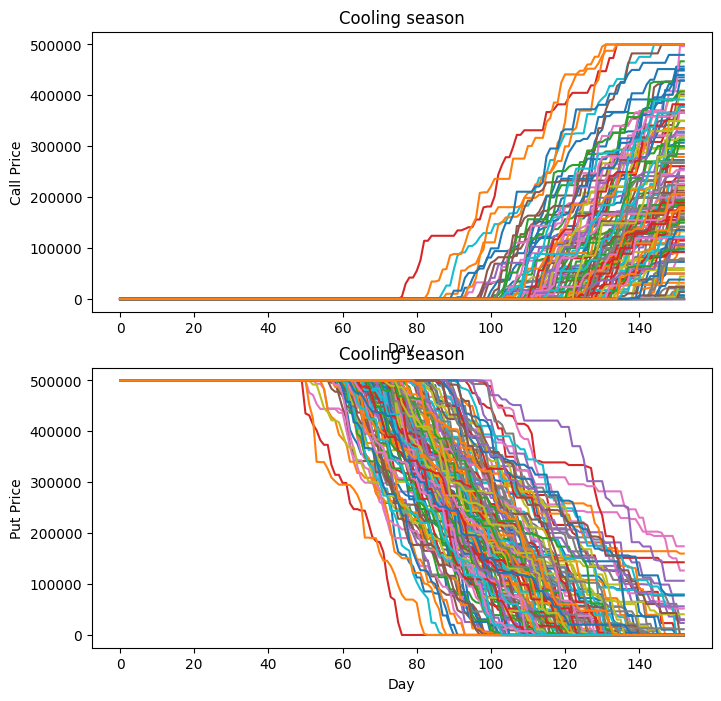

In [ ]:
#Plot the stock paths!

#seasons = ['Heating', 'Cooling']
seasons = ['Heating']
options = ['Call', 'Put']
Fig, axs = plt.subplots(len(options), len(seasons), figsize = (8,8))

for iszn in np.arange(0,len(seasons)):
  for iopt in np.arange(0, len(options)):
    season = seasons[iszn]
    option = options[iopt]
    if season == 'Heating':
      stockpaths = HeatingSznStockPaths
    elif season == 'Cooling':
      stockpaths = CoolingSznStockPaths

    npaths = np.shape(stockpaths)[1]
    for ipath in range(0, npaths-1):
      tempPath = stockpaths[ipath,:]
      optionPrice = GetCallPut(tempPath, option = option, season = season)
      axs[iopt].plot(optionPrice)
      axs[iopt].set_xlabel("Day")
      axs[iopt].set_ylabel(f"{option} Price")
      axs[iopt].set_title(f"{season} season")



In [ ]:
print(np.arange(0,2))


[0 1]
